In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [27]:
tiles = Table(fitsio.read('/global/cfs/cdirs/desi/spectro/redux/himalayas/tiles-himalayas.fits'))
print(len(tiles))
print(list(np.unique(tiles['SURVEY'])))
mask = tiles['SURVEY']=='sv1'
tiles = tiles[mask]
print(len(tiles))
print(list(np.unique(tiles['FAPRGRM'])))
print(list(np.unique(tiles['FAFLAVOR'])))

6234
['cmx', 'main', 'special', 'sv1', 'sv2', 'sv3']
185
['backup1', 'bgsmws', 'dc3r2', 'elg', 'elgqso', 'lrgqso', 'lrgqso2', 'mwclusgaldeep', 'praesepe', 'scndcosmos', 'scndhetdex', 'ssv', 'umaii', 'unwisebluebright', 'unwisebluefaint', 'unwisegreen']
['cmxelg', 'cmxlrgqso', 'sv1backup1', 'sv1bgsmws', 'sv1dc3r2', 'sv1elg', 'sv1elgqso', 'sv1lrgqso', 'sv1lrgqso2', 'sv1mwclusgaldeep', 'sv1praesepe', 'sv1scndcosmos', 'sv1scndhetdex', 'sv1ssv', 'sv1umaii', 'sv1unwisebluebright', 'sv1unwisebluefaint', 'sv1unwisegreen']


In [28]:
mask = (tiles['FAPRGRM']=='lrgqso') | (tiles['FAPRGRM']=='lrgqso2')
tiles = tiles[mask]
tiles.sort('TILEID')

In [29]:
tiles

TILEID,SURVEY,PROGRAM,FAPRGRM,FAFLAVOR,NEXP,EXPTIME,TILERA,TILEDEC,EFFTIME_ETC,EFFTIME_SPEC,EFFTIME_GFA,GOALTIME,OBSSTATUS,LRG_EFFTIME_DARK,ELG_EFFTIME_DARK,BGS_EFFTIME_BRIGHT,LYA_EFFTIME_DARK,GOALTYPE,MINTFRAC,LASTNIGHT
int32,str20,str6,str20,str20,int64,float64,float64,float64,float64,float64,float64,float64,str20,float64,float64,float64,float64,str20,float64,int32
80605,sv1,dark,lrgqso,cmxlrgqso,24,19559.1,36.448,-4.601,0.0,6854.3,0.0,4000.0,obsend,6573.8,6854.3,6832.2,6652.0,dark,0.9,20210205
80607,sv1,dark,lrgqso,cmxlrgqso,15,13500.8,106.74,56.1,0.0,9267.1,0.0,4000.0,obsend,8556.5,9267.1,8408.2,8092.6,dark,0.9,20201219
80609,sv1,dark,lrgqso,cmxlrgqso,15,13500.7,150.12,2.206,0.0,7781.9,0.0,4000.0,obsend,7673.7,7781.9,7981.7,10693.0,dark,0.9,20201217
80620,sv1,dark,lrgqso,sv1lrgqso,9,8100.5,144.0,65.0,0.0,7000.9,0.0,4000.0,obsend,6416.5,7000.9,6147.4,5818.2,dark,0.9,20201221
80622,sv1,dark,lrgqso,sv1lrgqso,6,5400.3,155.0,32.325,0.0,4901.2,0.0,4000.0,obsend,4677.1,4901.2,4702.0,6883.2,dark,0.9,20201221
80670,sv1,dark,lrgqso,sv1lrgqso,6,5327.9,38.0,-2.8,0.0,1896.2,0.0,4000.0,obsstart,1787.3,1896.2,1839.7,1660.0,dark,0.9,20210111
80674,sv1,dark,lrgqso,sv1lrgqso,19,16427.2,87.0,-23.2,0.0,4148.7,0.0,4000.0,obsend,4059.7,4148.7,4213.6,3291.8,dark,0.9,20210116
80676,sv1,dark,lrgqso,sv1lrgqso,11,9900.6,97.5,47.7,0.0,5702.7,0.0,4000.0,obsend,5261.3,5702.7,5185.8,4437.8,dark,0.9,20210109
80678,sv1,dark,lrgqso,sv1lrgqso,14,11776.7,102.5,39.0,0.0,5826.6,0.0,4000.0,obsend,5314.2,5826.6,5272.3,3803.1,dark,0.9,20210206


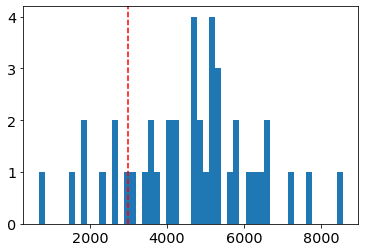

In [30]:
plt.hist(tiles['LRG_EFFTIME_DARK'], 50)
plt.axvline(3000, ls='--', color='r')
plt.show()

In [31]:
mask = tiles['LRG_EFFTIME_DARK']>3000.
print(np.sum(mask)/len(mask))

0.8095238095238095


In [32]:
mask = tiles['LRG_EFFTIME_DARK']>2000.
print(np.sum(mask)/len(mask))

0.9047619047619048


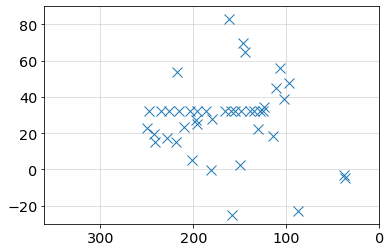

In [33]:
plt.plot(tiles['TILERA'], tiles['TILEDEC'], 'x', ms=10)
plt.grid(alpha=0.5)
plt.axis([360, 0, -30, 90])
plt.show()